# **Soal 2**
Pada sebuah kota besar bernama Kota A, energi listrik termasuk kebutuhan pokok yang relatif mahal. Meningkatnya krisis energi, maka sangat diperlukan efisiensi penggunaan energi listrik, terutama untuk efisiensi biaya bagi perusahaan, guna menekan biaya produksi. Energi listrik diindikasikan bergantung terhadap parameter cuaca. Sebagai contoh, jika temperatur rendah (dingin), maka pemakaian Air Conditioner (AC) menjadi turun, atau jika sinar matahari sangat terik, maka pemakaian AC cendrung lebih meningkat.

### **Pertanyaan/Tugas**
1. Hitunglah korelasi antara komponen cuaca yaitu temperature, humidity, precipitation, dan wind speed, terhadap electricity consumption.
2. Bangunlah model regresi linear antara komponen cuaca yang mempunyai correlation coefficient TERTINGGI (jika dibandingkan dengan electricity consumption) dengan electricity consumption dengan menggunakan Least Square Method ATAU Gradient Descent (lihat pertemuan 2, 3 dan 4).
    a. Visualisasikan data antara komponen cuaca terhadap electricty consumption dalam bentuk Scatter plot
    b. Visualisasikan hasil model regresi untuk poin (a) berupa garis linear dan tuliskan hasil model regresi (berupa persamaan garis)
    c. Bahas mengenai keakuratan dari model tsb


### Nomor 2 poin 1 

In [7]:
import pandas as pd
import statsmodels.api as sm

def hitung_r_squared_multi_fitur(df, kolom_target, kolom_fitur):
    r_squared_values = {}
    y = df[kolom_target]

    for fitur in kolom_fitur:
        X = df[[fitur]]  # Perhatikan tanda kurung ganda untuk membuat DataFrame
        X = sm.add_constant(X)  # Menambahkan konstanta (intercept) untuk model regresi

        model = sm.OLS(y, X).fit()
        r_squared_values[fitur] = model.rsquared

    return pd.Series(r_squared_values)

# Contoh Penggunaan
file_path = "Electricity Load Data.csv"
df = pd.read_csv(file_path)

kolom_target = 'Electricity Consumption (MWh)'
kolom_fitur = [col for col in df.columns if col != kolom_target and col != 'TIME']

r_squared_results = hitung_r_squared_multi_fitur(df, kolom_target, kolom_fitur)
print(r_squared_results)

Temperature (C)          0.426163
Humidity (%)             0.001347
Precipitation (l/m^2)    0.005345
Wind Speed (m/s)         0.009690
dtype: float64


In [4]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load dataset
file_path = "Electricity Load Data.csv"
df = pd.read_csv(file_path)

# Tentukan kolom target dan fitur
target_column = 'Electricity Consumption (MWh)'
feature_columns = [col for col in df.columns if col != target_column and col != 'TIME']

# Hitung R² score untuk setiap fitur cuaca terhadap konsumsi listrik
r2_results = {}

for feature in feature_columns:
    X = df[[feature]]  # Feature harus dalam bentuk DataFrame, bukan Series
    y = df[target_column]

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)

    r2 = r2_score(y, X)
    r2_results[feature] = r2

# Tampilkan hasil R² dalam bentuk terurut
r2_series = pd.Series(r2_results, name='R² Score').sort_values(ascending=False)

print("R² Score tiap komponen cuaca terhadap konsumsi listrik:")
print(r2_series)


R² Score tiap komponen cuaca terhadap konsumsi listrik:
Temperature (C)         -36.180635
Wind Speed (m/s)        -37.068761
Precipitation (l/m^2)   -37.923525
Humidity (%)            -37.927530
Name: R² Score, dtype: float64


In [96]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

df = pd.read_csv("Electricity Load Data.csv")

df.columns = ['TIME', 'Temperature', 'Humidity', 'Precipitation', 'WindSpeed', 'Electricity']
df.dropna(inplace=True)

df.head()
features = ['Temperature', 'Humidity', 'Precipitation', 'WindSpeed']
r2_scores = {}

for feature in features:
    X = df[[feature]]
    y = df['Electricity']
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    r2_scores[feature] = r2_score(y, y_pred)


# NOMOR 2 POIN 1
print("R² Score per Feature:")
print(r2_scores)


# ambil temperatur sebagai fitur utama karena korelasi paling tinggi
X_all = df[['Temperature']].copy()
y_all = df['Electricity'].copy()


R² Score per Feature:
{'Temperature': 0.42616266485907606, 'Humidity': 0.0013473180271121876, 'Precipitation': 0.005344861994151073, 'WindSpeed': 0.009689528413498905}


### Nomor 2 poin 2 

In [97]:
# LEAST SQUARES

X_ls = X_all.copy()
y_ls = y_all.copy()

model_ls = LinearRegression()
model_ls.fit(X_ls, y_ls)
y_pred_ls = model_ls.predict(X_ls)

residuals_ls = y_ls.values.reshape(-1, 1) - y_pred_ls.reshape(-1, 1)
sse_ls = np.sum(residuals_ls ** 2)
mse_ls = mean_squared_error(y_ls, y_pred_ls)
rmse_ls = np.sqrt(mse_ls)
mae_ls = mean_absolute_error(y_ls, y_pred_ls)
r2_ls = r2_score(y_ls, y_pred_ls)

print("\nLEAST SQUARES")
print(f"Persamaan Regresi: Electricity = {model_ls.coef_[0]:.4f} * Temperature + {model_ls.intercept_:.2f}")
print(f"R² Score       : {r2_ls:.4f}")
print(f"SSE (LS)       : {sse_ls:.2f}")
print(f"MSE (LS)       : {mse_ls:.2f}")
print(f"RMSE (LS)      : {rmse_ls:.2f}")
print(f"MAE (LS)       : {mae_ls:.2f}")



LEAST SQUARES
Persamaan Regresi: Electricity = 74.8359 * Temperature + -867.57
R² Score       : 0.4262
SSE (LS)       : 1017112891.01
MSE (LS)       : 21168.68
RMSE (LS)      : 145.49
MAE (LS)       : 119.41


In [98]:
# GRADIENT DESCENT
def gradient_descent(X, y, alpha=0.0001, iterations=10000):
    m = len(y)
    X_b = np.c_[np.ones((m, 1)), X]
    theta = np.zeros((2, 1))
    y = y.values.reshape(-1, 1).copy()
    
    for _ in range(iterations):
        gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
        theta -= alpha * gradients
    return theta

X_gd = X_all.copy()
y_gd = y_all.copy()

theta_gd = gradient_descent(X_gd, y_gd)
y_pred_gd = theta_gd[0] + theta_gd[1] * X_gd.values.reshape(-1, 1)

residuals_gd = y_gd.values.reshape(-1, 1) - y_pred_gd
sse_gd = np.sum(residuals_gd ** 2)
mse_gd = np.mean(residuals_gd ** 2)
rmse_gd = np.sqrt(mse_gd)
mae_gd = mean_absolute_error(y_gd, y_pred_gd)
r2_gd = r2_score(y_gd, y_pred_gd)

print("\nGRADIENT DESCENT")
print(f"Persamaan Regresi: Electricity = {theta_gd[1][0]:.4f} * Temperature + {theta_gd[0][0]:.2f}")
print(f"R² Score       : {r2_gd:.4f}")
print(f"SSE (GD)       : {sse_gd:.2f}")
print(f"MSE (GD)       : {mse_gd:.2f}")
print(f"RMSE (GD)      : {rmse_gd:.2f}")
print(f"MAE (GD)       : {mae_gd:.2f}")



GRADIENT DESCENT
Persamaan Regresi: Electricity = 43.4667 * Temperature + -4.87
R² Score       : 0.3510
SSE (GD)       : 1150329743.76
MSE (GD)       : 23941.26
RMSE (GD)      : 154.73
MAE (GD)       : 131.44


### Nomor 2 poin 2.a (visualisasi scatter plot)

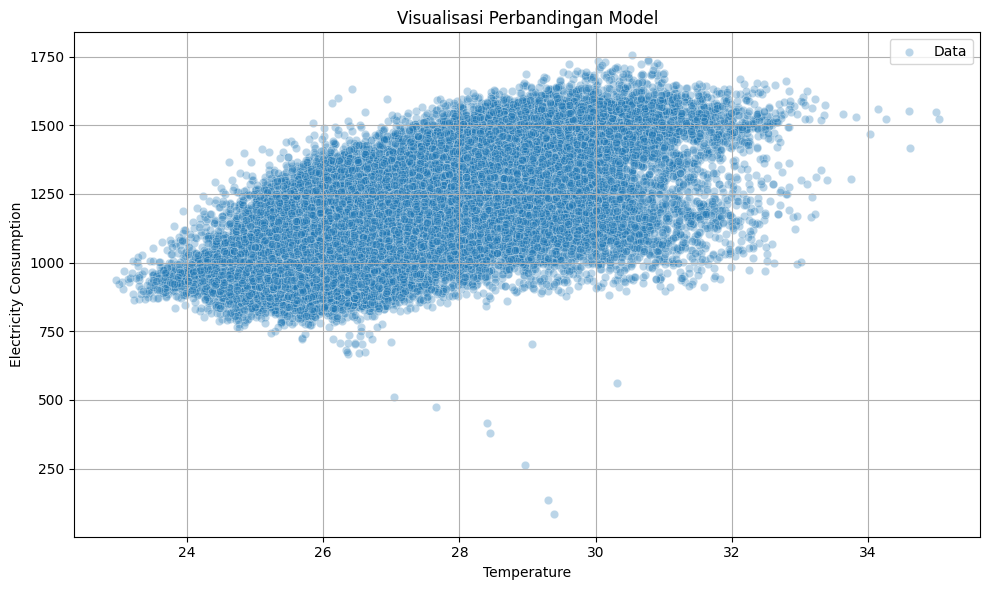

In [99]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature', y='Electricity', data=df, alpha=0.3, label='Data')
plt.title('Visualisasi Perbandingan Model')
plt.xlabel('Temperature')
plt.ylabel('Electricity Consumption')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Nomor 2 poin 2.a (visualisasi model regresi berupa garis linear)

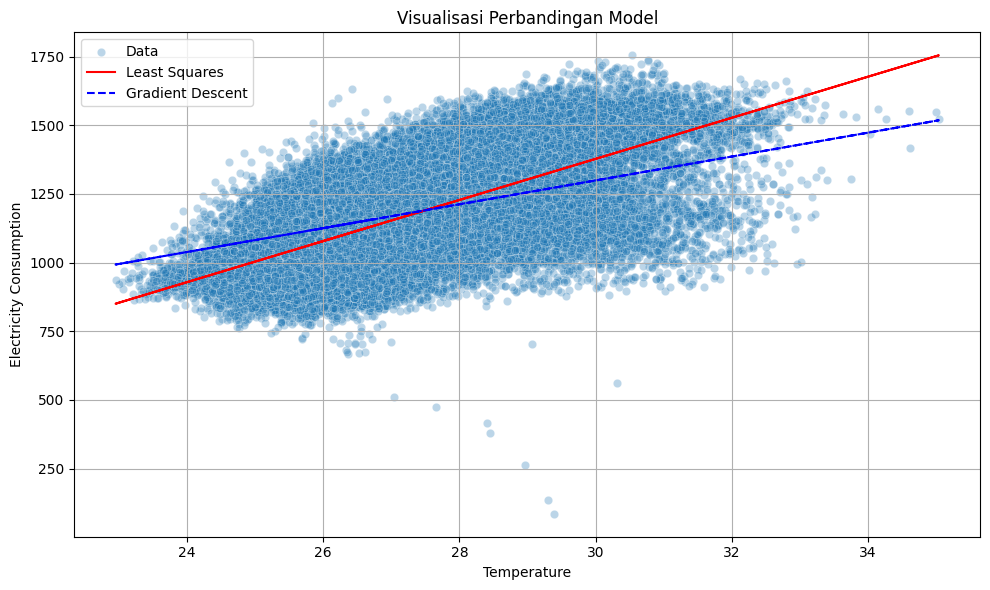

In [100]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature', y='Electricity', data=df, alpha=0.3, label='Data')

plt.plot(df['Temperature'], y_pred_ls, color='red', label='Least Squares')

plt.plot(df['Temperature'], y_pred_gd, color='blue', linestyle='--', label='Gradient Descent')

plt.title('Visualisasi Perbandingan Model')
plt.xlabel('Temperature')
plt.ylabel('Electricity Consumption')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Nomor 2 poin 2.c (pembahasan hasil keakuratan model)

In [101]:
comparison_table = pd.DataFrame({
    'Model': ['Least Squares', 'Gradient Descent'],
    'R²': [r2_ls, r2_gd],           #  mendekati 1 lebih baik
    'SSE': [sse_ls, sse_gd],        #  mendekati 0 lebih baik
    'MSE': [mse_ls, mse_gd],        #  mendekati 0 lebih baik
    'RMSE': [rmse_ls, rmse_gd],     #  mendekati 0 lebih baik
    'MAE': [mae_ls, mae_gd]         #  mendekati 0 lebih baik
})

better = {
    'R²': comparison_table['R²'].idxmax(),  
    'SSE': comparison_table['SSE'].idxmin(),           
    'MSE': comparison_table['MSE'].idxmin(),
    'RMSE': comparison_table['RMSE'].idxmin(),
    'MAE': comparison_table['MAE'].idxmin()
}

# Tambahkan kolom "Better Score"
for col in ['R²', 'SSE', 'MSE', 'RMSE', 'MAE']:
    comparison_table[col + ' '] = ['✓' if i == better[col] else '' for i in comparison_table.index]

# Cetak hasil akhir
print(comparison_table)


              Model        R²           SSE           MSE        RMSE  \
0     Least Squares  0.426163  1.017113e+09  21168.683213  145.494616   
1  Gradient Descent  0.351004  1.150330e+09  23941.261733  154.729641   

          MAE R²  SSE  MSE  RMSE  MAE   
0  119.408755   ✓    ✓    ✓     ✓    ✓  
1  131.437901                           


berdasarkan hasil tabel diatas terlihat bahwa least squares berhasil mengungguli model gradient decent pada matrix SSE, MSE, RMSE, dan MAE